# Exercise

You are given bhp.csv which contains property prices in the city of banglore, India. You need to examine price_per_sqft column and do following,

(1) Remove outliers using percentile technique first. Use [0.001, 0.999] for lower and upper bound percentiles

(2) After removing outliers in step 1, you get a new dataframe.

(3) On step(2) dataframe, use 4 standard deviation to remove outliers

(4) Plot histogram for new dataframe that is generated after step (3). Also plot bell curve on same histogram

(5) On step(2) dataframe, use zscore of 4 to remove outliers. This is quite similar to step (3) and you will get exact same result

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import warnings 
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
bhp = pd.read_csv('datasets/bhp.csv')
bhp.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [3]:
bhp.shape

(13200, 7)

In [4]:
bhp.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13200.000000,13200.000000,13200.000000,13200.000000,1.320000e+04
mean,1555.302783,2.691136,112.276178,2.800833,7.920337e+03
std,1237.323445,1.338915,149.175995,1.292843,1.067272e+05
min,1.000000,1.000000,8.000000,1.000000,2.670000e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.267000e+03
50%,1275.000000,2.000000,71.850000,3.000000,5.438000e+03
75%,1672.000000,3.000000,120.000000,3.000000,7.317000e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


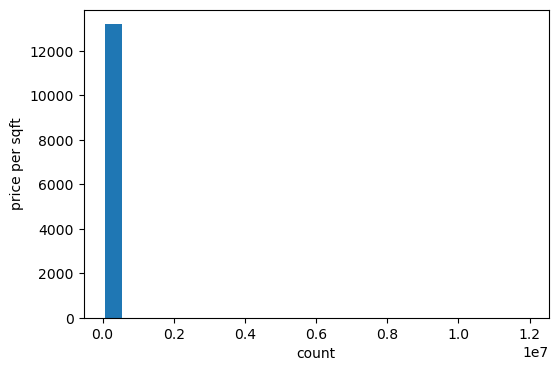

In [71]:
plt.figure(figsize=(6,4))
plt.hist(bhp.price_per_sqft, bins=20, rwidth=0.8)
plt.xlabel('count')
plt.ylabel('price per sqft')

plt.show()

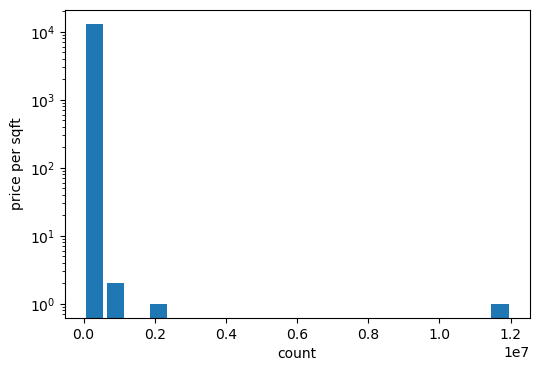

In [72]:
plt.figure(figsize=(6,4))
plt.hist(bhp.price_per_sqft, bins=20, rwidth=0.8)
plt.yscale('log')
plt.xlabel('count')
plt.ylabel('price per sqft')

plt.show()


# step one

In [6]:
lower, upper = bhp.price_per_sqft.quantile([0.001, 0.999])

lower, upper

(1366.184, 50959.36200000098)

In [46]:
outliers = bhp[(bhp.price_per_sqft > upper) | (bhp.price_per_sqft < lower)]
outliers.head(5)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
345,other,3 Bedroom,11.0,3.0,74.0,3,672727
665,Yelahanka,3 BHK,35000.0,3.0,130.0,3,371
798,other,4 Bedroom,10961.0,4.0,80.0,4,729
1005,other,1 BHK,15.0,1.0,30.0,1,200000
1106,other,5 Bedroom,24.0,2.0,150.0,5,625000


# step two

In [8]:
df =  bhp[(bhp.price_per_sqft < upper) & (bhp.price_per_sqft > lower)]
df.shape

(13172, 7)

In [9]:
bhp.shape[0] - df.shape[0]

28

# step three

In [10]:
upper_limit = df['price_per_sqft'].mean() + 4*df['price_per_sqft'].std()
upper_limit

23227.73653589429

In [11]:
lower_limit = df['price_per_sqft'].mean() - 4*df['price_per_sqft'].std()
lower_limit

-9900.429065502549

In [47]:
outlier = df[(df.price_per_sqft > upper_limit) | (df.price_per_sqft < lower_limit) ]
outlier.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft,z_score
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274,7.150495
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333,6.440283
190,Bellandur,4 Bedroom,1200.0,5.0,325.0,4,27083,4.930994
733,Cunningham Road,4 BHK,5270.0,4.0,1250.0,4,23719,4.118633
760,other,9 Bedroom,600.0,9.0,190.0,9,31666,6.037725


In [49]:
df2 = df[(df.price_per_sqft < upper_limit) & (df.price_per_sqft > lower_limit) ]
df2.sample(5)

,location,size,total_sqft,bath,price,bhk,price_per_sqft,z_score
4193,Electronic City Phase II,3 BHK,993.0,2.0,50.0,3,5035,-0.393298
323,Haralur Road,3 BHK,1464.0,3.0,56.0,3,3825,-0.685496
7810,Whitefield,4 Bedroom,5200.0,5.0,242.0,4,4653,-0.485545
11325,other,3 Bedroom,2800.0,3.0,400.0,3,14285,1.840451
7044,Amruthahalli,4 Bedroom,600.0,4.0,60.0,4,10000,0.805682


In [30]:
df.shape[0] - df2.shape[0] 

125

In [14]:
df2.shape

(13047, 7)

# step four

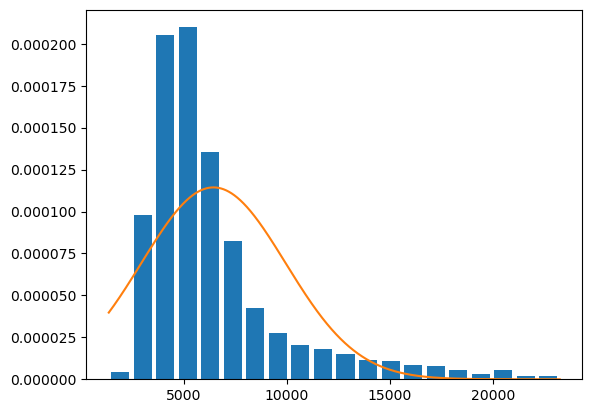

In [65]:
plt.hist(df2.price_per_sqft, bins=20, rwidth=0.8, density = True)

rng = np.arange(df2.price_per_sqft.min(), df2.price_per_sqft.max(), 0.1)
plt.plot(rng, norm.pdf(rng, df2.price_per_sqft.mean(), df2.price_per_sqft.std()))

plt.show()

# step five

In [67]:
df['z_score'] = (df['price_per_sqft'] - df['price_per_sqft'].mean())/df['price_per_sqft'].std()
df.sample(5)

,location,size,total_sqft,bath,price,bhk,price_per_sqft,z_score
8821,Thanisandra,3 BHK,1573.0,3.0,98.00,3,6230,-0.104721
8977,Varthur,2 BHK,1035.0,2.0,60.00,2,5797,-0.209285
1066,Banashankari,3 BHK,1470.0,2.0,88.64,3,6029,-0.153260
6863,Lakshminarayana Pura,3 BHK,1649.0,3.0,150.00,3,9096,0.587378
6075,other,2 BHK,1191.0,2.0,90.00,2,7556,0.215489


In [68]:
outliers2= df[(df.z_score> 4) | (df.z_score < -4)]
outliers2.sample(5)

,location,size,total_sqft,bath,price,bhk,price_per_sqft,z_score
12948,other,10 Bedroom,7150.0,13.0,3600.0,10,50349,10.549415
3136,other,4 Bedroom,1200.0,4.0,350.0,4,29166,5.434010
9229,1st Phase JP Nagar,4 Bedroom,1200.0,4.0,300.0,4,25000,4.427977
13013,other,4 Bedroom,1200.0,5.0,350.0,4,29166,5.434010
5747,other,5 Bedroom,1200.0,5.0,300.0,5,25000,4.427977


In [69]:
final = df[(df.z_score > -4) & (df.z_score < 4)]
final.shape

(13047, 8)

In [70]:
 df.shape[0] - final.shape[0]

125